# Importing Libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(21)

#ML Libraries 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# Loading Test and Train Dataset

In [2]:
data_train = pd.read_csv('/kaggle/input/titanic/train.csv')
data_test = pd.read_csv('/kaggle/input/titanic/test.csv')

In [3]:
display(data_train.shape, data_train.head())

(891, 12)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
display(data_test.shape, data_test.head())

(418, 11)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
data_train_info = pd.DataFrame(columns=['Name of Col', 'Num of Null', 'Dtype', 'N_Unique'])

for i in range(0, len(data_train.columns)):
    data_train_info.loc[i] = [data_train.columns[i],
                        data_train[data_train.columns[i]].isnull().sum(),
                        data_train[data_train.columns[i]].dtypes,
                        data_train[data_train.columns[i]].nunique()] 
data_train_info

,Name of Col,Num of Null,Dtype,N_Unique
0,PassengerId,0,int64,891
1,Survived,0,int64,2
2,Pclass,0,int64,3
3,Name,0,object,891
4,Sex,0,object,2
5,Age,177,float64,88
6,SibSp,0,int64,7
7,Parch,0,int64,7
8,Ticket,0,object,681
9,Fare,0,float64,248


([<matplotlib.axis.XTick at 0x7f195c907310>,
 [Text(0, 0, 'PassengerId'),
  Text(1, 0, 'Survived'),
  Text(2, 0, 'Pclass'),
  Text(3, 0, 'Name'),
  Text(4, 0, 'Sex'),
  Text(5, 0, 'Age'),
  Text(6, 0, 'SibSp'),
  Text(7, 0, 'Parch'),
  Text(8, 0, 'Ticket'),
  Text(9, 0, 'Fare'),
  Text(10, 0, 'Cabin'),
  Text(11, 0, 'Embarked')])

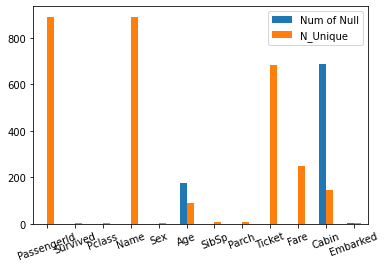

In [6]:
data_train_info.plot.bar() 
plt.xticks(ticks=[0,1,2,3,4,5,6,7,8,9,10,11], labels=data_train_info['Name of Col'], rotation=20)

From the above bar plot it is clear that, two features have NaN values. 
**Age** and **Cabin**. We will need to treat these features before building the ML Model.

In [7]:
data_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Exploratory Data Analysis

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='Survived', ylabel='count'>

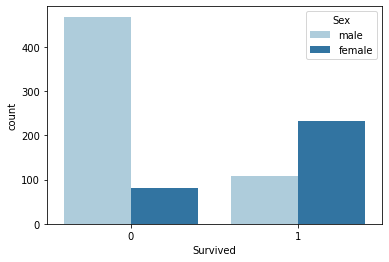

In [8]:
sns.countplot(data_train['Survived'], hue=data_train['Sex'],palette= 'Paired')

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='Survived', ylabel='count'>

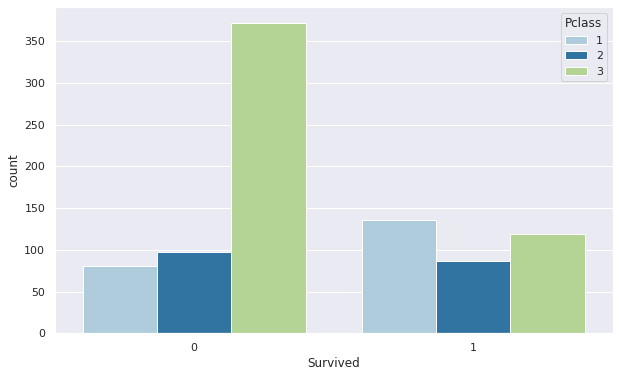

In [9]:
sns.set(rc={"figure.figsize":(10, 6)})
sns.countplot(data_train['Survived'], hue=data_train['Pclass'],palette= 'Paired')

From the above countplot, we infer that -
- No of deads were more than the survived
- More male passengers died compared to female
- Majority of People who died were travelling in 3rd class


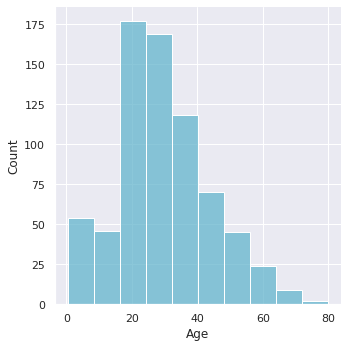

In [10]:
sns.displot(data_train['Age'].dropna(), color='c', bins=10)

Majority of passengers were 18 to 32 years old. 

Now, let us check how many passengers were travelling alone, or with Sibilings/Spouse with the help of a countplot-

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='SibSp', ylabel='count'>

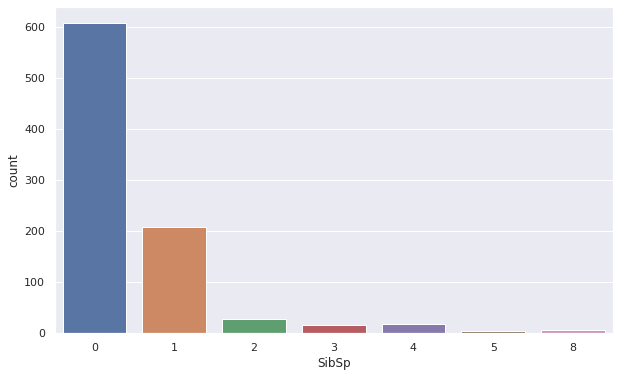

In [11]:
sns.countplot(data_train["SibSp"])

From the above plot we infer that.. 
Majority of passengers were Solo Travellers, followed by Travelling with Spouse.

<AxesSubplot:xlabel='Fare', ylabel='Count'>

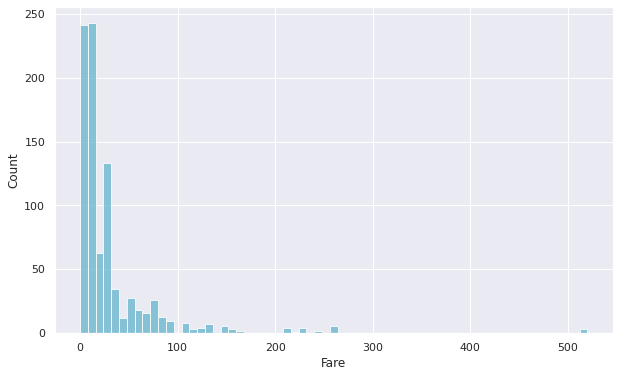

In [12]:
sns.set(rc={"figure.figsize":(10, 6)})
sns.histplot(data_train["Fare"], color='c', binwidth=8)

# Treating NaN Values and Data Cleaning

From the above analysis, we know that - 
**Age(177 values)** and **Cabin(687 values)** features have NaN values. 

First treating the **Age** feature -

Lets analyze the **Age** and **PClass** to find if there is anyrealtion between them. This might be helpful in imputing the NaN values.

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

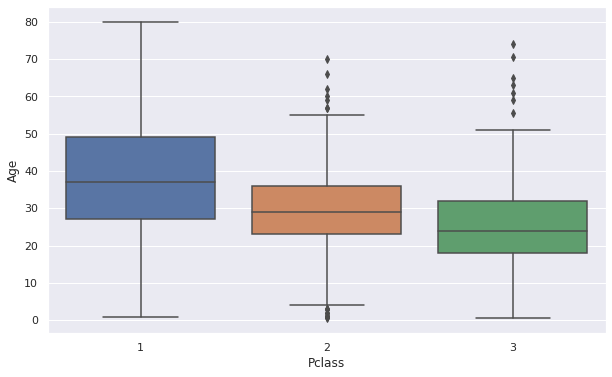

In [13]:
sns.boxplot(data=data_train, y=data_train['Age'], x=data_train['Pclass'])

From the above boxplot it is clear that.. 
- The average age of passengers travelling in 1st class is 37 Years.
- The average age of passengers travelling in 2st class is 28 Years.
- The average age of passengers travelling in 3rd class is 24 Years.

We can use these moedians to impute the Age feature of test dataset.

In [14]:
def imputeAge(y):
    Age = y[0]
    Pclass = y[1]
    
    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        if Pclass ==2:
            return 28
        if Pclass ==3:
            return 25      
    else:
        return Age

In [15]:
data_train['Age'] = data_train[['Age','Pclass']].apply(imputeAge,axis=1)
data_test['Age'] = data_test[['Age','Pclass']].apply(imputeAge,axis=1)

Since, **Cabin** and **Embarked** column will not play an important role in our model building.
Hence, we can drop this column.

In [16]:
data_train.drop(['Cabin', 'Embarked'], axis=1, inplace =True)

In [17]:
data_test.drop(['Cabin','Embarked'], axis=1, inplace = True)

Other columns like **Ticket**, **Name**, **Fare** and **PassengerId** should be dropped, as these will not play any role in our model.

In [18]:
data_train.drop(['Ticket','Name','Fare','PassengerId'], axis=1, inplace = True)

In [19]:
data_test.drop(['Ticket','Name','Fare','PassengerId'], axis=1, inplace = True)

In [20]:
data_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0


In [21]:
data_test.head()

,Pclass,Sex,Age,SibSp,Parch
0,3,male,34.5,0,0
1,3,female,47.0,1,0
2,2,male,62.0,0,0
3,3,male,27.0,0,0
4,3,female,22.0,1,1


Now, from the above outputs we can see that we have a categorical variable **Sex**, lets encode this feature.

In [22]:
#Encoding Sex feature
data_train = pd.get_dummies(data_train)
data_test = pd.get_dummies(data_test)

Now our datasets are ready and we can start with model building.


# Building the ML Models 

### Defining Features and Target Variable

In [23]:
#Defining X and y
X = data_train.drop('Survived', axis =1 )
y = data_train['Survived']

### Train Test Split

In [24]:
X_train,X_test,y_train ,y_test=train_test_split(X, y ,test_size = 0.2)

### Building the ML Model

#### Random Forest Classifier

In [25]:
rfc_model = RandomForestClassifier(n_estimators = 150 ) # n_estimators refers to the number of decision tree algorithms used

In [26]:
rfc_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150)

In [27]:
y_pred_test = rfc_model.predict(X_test)

In [28]:
#Calculating the accuracy of the RFC model
print("Accuracy score of RFC model on test dataset is : ")
print(accuracy_score(y_test, y_pred_test))

Accuracy score of RFC model on test dataset is : 
0.8324022346368715


In [29]:
y_pred_train = rfc_model.predict(X_train)

print("Accuracy score of RFC model on train dataset is : ")
print(accuracy_score(y_train, y_pred_train))

Accuracy score of RFC model on train dataset is : 
0.9213483146067416


By the RFC, we can achieve the accuracy score of 0.83.
We can also try to create other models to get a better model.